# TASK 4: Sales Prediction Using Python

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
## Load data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Advertising.csv")


Saving Advertising.csv to Advertising.csv


Data Exploration and Preprocessing

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.columns = [str(c).strip().strip('"') for c in df.columns]
for c in list(df.columns):
    if c.lower().startswith('unnamed') or c == '':
        df = df.drop(columns=[c])

In [7]:
df.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


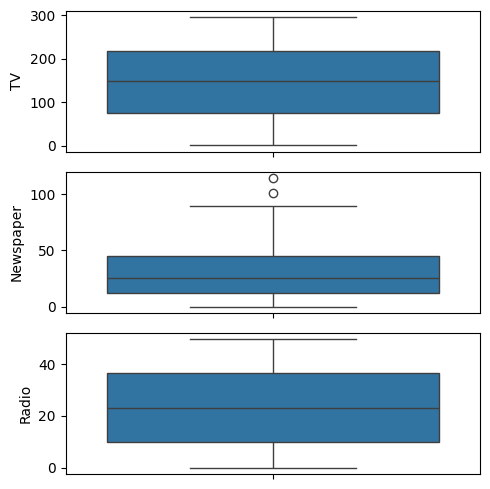

In [9]:
## Outlier Analysis
fig, axs = plt.subplots(3, figsize = (5,5))
plt1 = sns.boxplot(df['TV'], ax = axs[0])
plt2 = sns.boxplot(df['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df['Radio'], ax = axs[2])
plt.tight_layout()

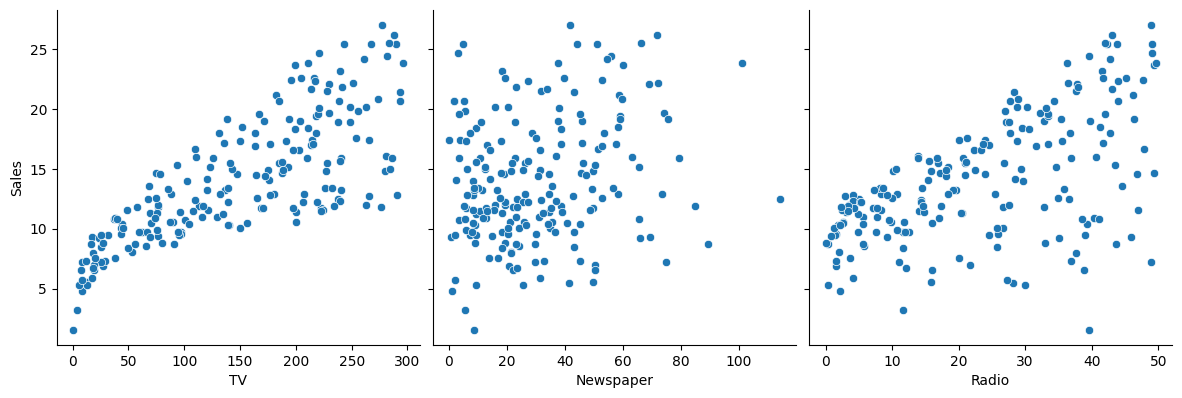

In [10]:
## Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(df, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

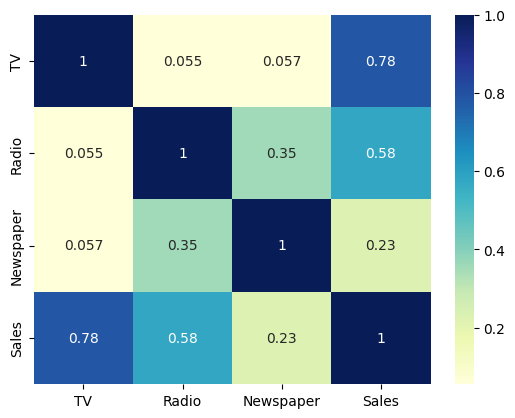

In [12]:
## Let's see the correlation between different variables.
sns.heatmap(df.corr(), cmap="YlGnBu", annot = True)
plt.show()

The detailed correlation heatmap is displayed above and here are the key insights:

* TV and Sales (0.78): There is a strong positive correlation between TV advertising and Sales. This means that as TV advertising spend increases, sales tend to increase significantly.

* **Radio and Sales (0.58)**: Radio advertising also shows a moderately strong positive correlation with Sales, though not as strong as TV. Increased radio spend is associated with increased sales.

* **Newspaper and Sales (0.23)**: Newspaper advertising has a weak positive correlation with Sales. This reinforces the earlier findings that its impact on sales is much less pronounced compared to TV and Radio.

* **TV and Radio (0.06)**: There is a very weak positive correlation between TV and Radio advertising. This suggests that spending on one channel does not strongly influence spending on the other.

* **TV and Newspaper (0.06)**: Similarly, TV and Newspaper advertising have a very weak positive correlation.

* **Radio and Newspaper (0.35)**: There's a moderate positive correlation between Radio and Newspaper advertising. This indicates that companies that spend more on Radio might also tend to spend more on Newspaper ads, or vice-versa, but it's not a very strong relationship.

In summary, the heatmap visually confirms that TV advertising has the strongest linear relationship with sales, followed by Radio, while Newspaper advertising has a much weaker connection. The advertising channels themselves are not highly correlated with each other, suggesting that budget allocation decisions can consider their individual impacts without strong concern for multicollinearity between the ad channels themselves.

In [15]:
## Handling all the outliers in the data and that we have seen from data visualisation plots
def remove_outliers(col):
    d25=df[col].quantile(0.25)
    d75=df[col].quantile(0.75)
    diqr=d75-d25
    upper_lim=d75+1.5*diqr
    lower_lim=d25-1.5*diqr
    filter_df=df[ (df[col] >= lower_lim) & (df[col] <= upper_lim) ]
    return filter_df

df=remove_outliers('TV')
df=remove_outliers('Radio')
df=remove_outliers('Newspaper')
df=remove_outliers('Sales')

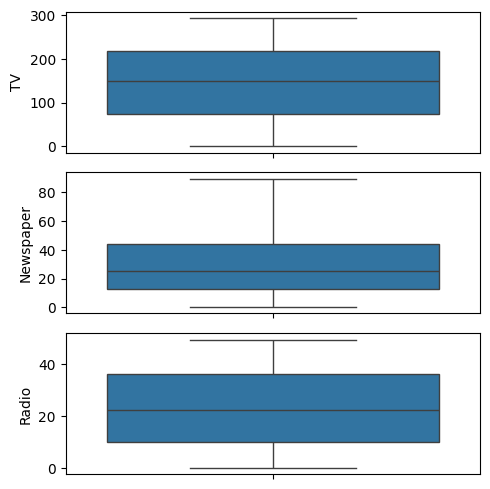

In [16]:
## Outlier Analysis after removing outliers
fig, axs = plt.subplots(3, figsize = (5,5))
plt1 = sns.boxplot(df['TV'], ax = axs[0])
plt2 = sns.boxplot(df['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df['Radio'], ax = axs[2])
plt.tight_layout()

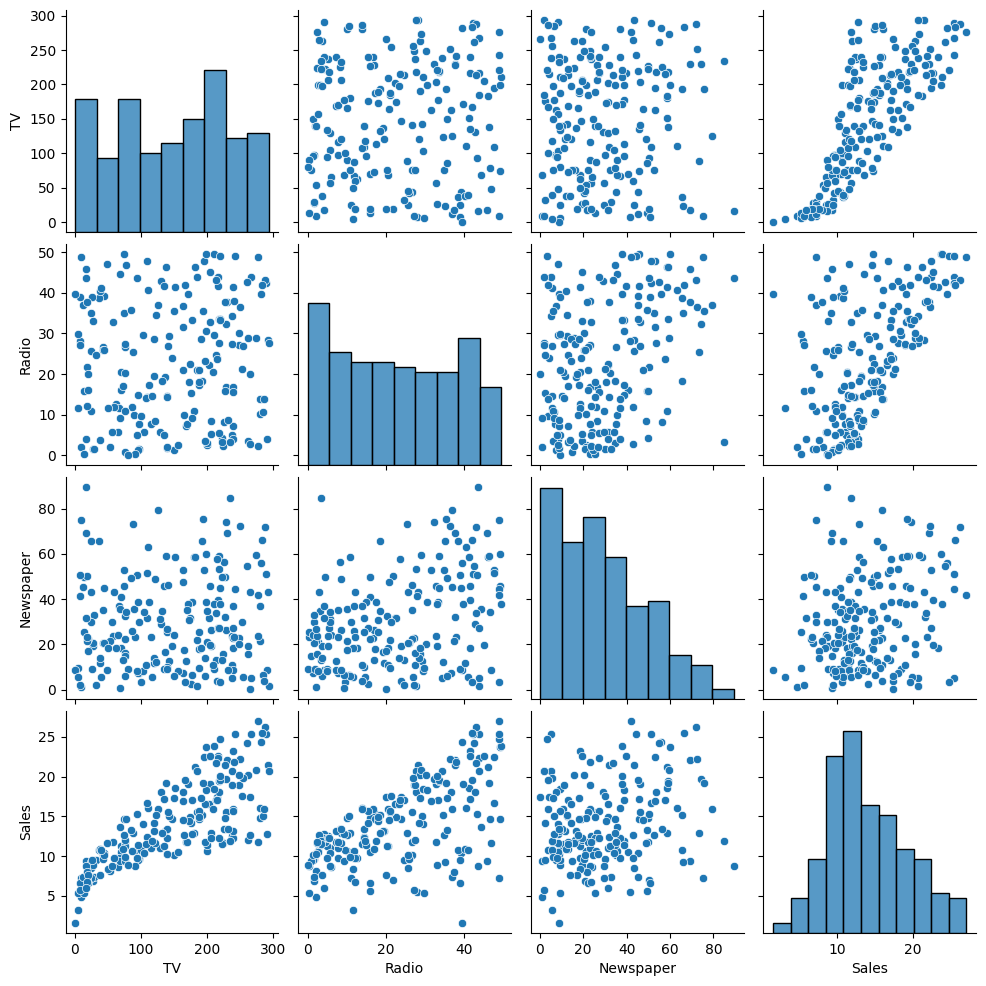

In [17]:
## Pairplot of numerical features after removing outliers
sns.pairplot(df[['TV', 'Radio', 'Newspaper', 'Sales']])
plt.show()

Model Building

In [18]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [19]:
X = df[["TV","Radio","Newspaper"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.head()

,TV,Radio,Newspaper
139,184.9,43.9,1.7
5,8.7,48.9,75.0
67,139.3,14.5,10.2
140,73.4,17.0,12.9
106,25.0,11.0,29.7


In [21]:
y_train.head()

,Sales
139,20.7
5,7.2
67,13.4
140,10.9
106,7.2


In [22]:
## Linear
lr = LinearRegression().fit(X_train, y_train)
## Ridge
ridge = Ridge(); params = {"alpha":[0.01,0.1,1,10,100]}
ridge_cv = GridSearchCV(ridge, params, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='neg_root_mean_squared_error').fit(X_train, y_train)
ridge_best = ridge_cv.best_estimator_

## RF
rf = RandomForestRegressor(n_estimators=500, random_state=42).fit(X_train, y_train)

## Evaluate
def metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.maximum(1e-9, np.array(y_true)))) * 100)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE_%': mape}

res = {
    'LinearRegression': {'test': metrics(y_test, lr.predict(X_test)), 'coef': dict(zip(["TV","Radio","Newspaper"], lr.coef_.tolist()))},
    'Ridge': {'best_alpha': ridge_cv.best_params_['alpha'], 'test': metrics(y_test, ridge_best.predict(X_test)), 'coef': dict(zip(["TV","Radio","Newspaper"], ridge_best.coef_.tolist()))},
    'RandomForest': {'test': metrics(y_test, rf.predict(X_test)), 'feature_importances': dict(zip(["TV","Radio","Newspaper"], rf.feature_importances_.tolist()))}
}
res

{'LinearRegression': {'test': {'RMSE': 1.6555699642993027,
   'MAE': 1.2497394075236383,
   'MAPE_%': 11.737244572650821},
  'coef': {'TV': 0.045228855218888725,
   'Radio': 0.18239274811379014,
   'Newspaper': 0.005042907687915127}},
 'Ridge': {'best_alpha': 100,
  'test': {'RMSE': 1.6578001684066348,
   'MAE': 1.2521129492004175,
   'MAPE_%': 11.745390001142365},
  'coef': {'TV': 0.04522826815527838,
   'Radio': 0.1817970920978298,
   'Newspaper': 0.005201370111185945}},
 'RandomForest': {'test': {'RMSE': 0.6515672160260789,
   'MAE': 0.5436349999999808,
   'MAPE_%': 4.602724528711357},
  'feature_importances': {'TV': 0.6362333670908876,
   'Radio': 0.354522375928721,
   'Newspaper': 0.009244256980391536}}}

In [23]:
print(f"Best alpha: {ridge_cv.best_params_['alpha']}")

Best alpha: 100


In [24]:
X = sm.add_constant(X_train)
model = sm.OLS(y_train, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     431.1
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.12e-74
Time:                        01:08:08   Log-Likelihood:                -306.93
No. Observations:                 158   AIC:                             621.9
Df Residuals:                     154   BIC:                             634.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9799      0.355      8.399      0.0

This output provides a comprehensive statistical summary of the regression model. Key takeaways from this model include:

* High R-squared (0.894): Indicates that approximately 89.4% of the variance in sales can be explained by the advertising expenditures on TV, Radio, and Newspaper.
* Significant Predictors: Both TV and Radio advertising expenditures are highly statistically significant predictors of sales (p-values < 0.001), with positive coefficients.
* Non-significant Predictor: Newspaper advertising expenditure is not statistically significant (p-value = 0.476), suggesting it does not have a linear relationship with sales after accounting for TV and Radio advertising.

This model suggests that TV and Radio advertising are effective in driving sales, with TV having a slightly higher coefficient, while Newspaper advertising has a negligible impact in this specific model.

In [25]:
## Elasticities via log-log
log_df = df.copy()
log_df['log_Sales'] = np.log(log_df['Sales'])
log_df['log_TV'] = np.log(log_df['TV'] + 1)
log_df['log_Radio'] = np.log(log_df['Radio'] + 1)
log_df['log_Newspaper'] = np.log(log_df['Newspaper'] + 1)
X_log = log_df[['log_TV','log_Radio','log_Newspaper']]; y_log = log_df['log_Sales']
log_lr = LinearRegression().fit(X_log, y_log)
elasticities = dict(zip(['TV','Radio','Newspaper'], log_lr.coef_.tolist()))
elasticities

{'TV': 0.36450182481468724,
 'Radio': 0.19990108650759686,
 'Newspaper': 0.016837480975487262}

In [30]:
## Scenario simulator (percent changes on mean spend)
mean_row = X_train.mean()
lr_baseline = lr.predict(pd.DataFrame([mean_row]))[0]

def simulate(change_dict):
    new_row = mean_row.copy()
    for k, pct in change_dict.items():
        if k in new_row.index: new_row[k] = new_row[k] * (1 + pct)

    pred = lr.predict(pd.DataFrame([new_row]))[0]
    return {'baseline': lr_baseline, 'scenario': pred, 'uplift': pred - lr_baseline, 'uplift_%': (pred - lr_baseline)/lr_baseline*100}

sim_tv20 = simulate({'TV':0.20}); sim_radio20 = simulate({'Radio':0.20}); sim_news20 = simulate({'Newspaper':0.20})
sim_tv20, sim_radio20, sim_news20

({'baseline': np.float64(14.031645569620252),
  'scenario': np.float64(15.372801355462784),
  'uplift': np.float64(1.3411557858425311),
  'uplift_%': np.float64(9.558079123280105)},
 {'baseline': np.float64(14.031645569620252),
  'scenario': np.float64(14.870629123254053),
  'uplift': np.float64(0.8389835536338008),
  'uplift_%': np.float64(5.979224243308098)},
 {'baseline': np.float64(14.031645569620252),
  'scenario': np.float64(14.061855778384592),
  'uplift': np.float64(0.03021020876433944),
  'uplift_%': np.float64(0.21530054058482775)})

The scenario simulator has successfully run, calculating the sales uplift from a 20% increase in advertising spend for each channel. Here's what the results indicate:

* **TV Advertising:** A 20% increase in TV advertising spend is projected to result in a 9.56% uplift in sales.
* **Radio Advertising:** A 20% increase in Radio advertising spend is projected to result in a 5.98% uplift in sales.
* **Newspaper Advertising:** A 20% increase in Newspaper advertising spend is projected to result in a relatively small 0.22% uplift in sales.

These results suggest that TV advertising has the most significant impact on sales for a proportional increase in spend, followed by Radio, with Newspaper advertising showing a much smaller effect. This aligns with the previously calculated elasticities and the coefficients from the linear regression model, where Newspaper advertising had a low or statistically insignificant impact

In [31]:
## Elasticities via log-log (moved from previous cell to ensure definition)
log_df = df.copy()
log_df['log_Sales'] = np.log(log_df['Sales'])
log_df['log_TV'] = np.log(log_df['TV'] + 1)
log_df['log_Radio'] = np.log(log_df['Radio'] + 1)
log_df['log_Newspaper'] = np.log(log_df['Newspaper'] + 1)
X_log = log_df[['log_TV','log_Radio','log_Newspaper']]; y_log = log_df['log_Sales']
log_lr = LinearRegression().fit(X_log, y_log)
elasticities = dict(zip(['TV','Radio','Newspaper'], log_lr.coef_.tolist()))

## Budget optimizer based on elasticities (Cobb-Douglas shares)
elas = pd.Series(elasticities).clip(lower=0)
shares = elas/elas.sum() if elas.sum()>0 else pd.Series({'TV':1/3,'Radio':1/3,'Newspaper':1/3})
B = float(X.mean().sum())
alloc_opt = (shares * B).to_dict()
shares, alloc_opt

(TV           0.627110
 Radio        0.343922
 Newspaper    0.028968
 dtype: float64,
 {'TV': 126.8116211264716,
  'Radio': 69.54637568099754,
  'Newspaper': 5.857825977340974})

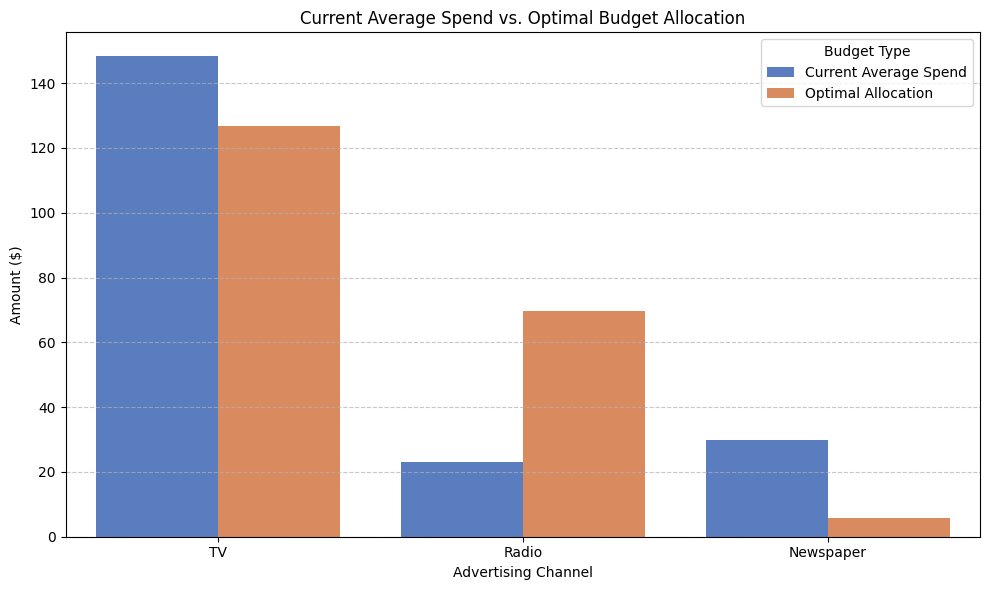

In [33]:

## Convert mean_row (current average spend) to a dictionary for consistency
current_spend = mean_row.to_dict()

## Create a DataFrame for plotting
budget_comparison = pd.DataFrame({
    'Current Average Spend': current_spend,
    'Optimal Allocation': alloc_opt})

budget_comparison_melted = budget_comparison.reset_index().melt(id_vars='index', var_name='Type', value_name='Amount')
budget_comparison_melted.rename(columns={'index': 'Advertising Channel'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Advertising Channel', y='Amount', hue='Type', data=budget_comparison_melted, palette='muted')
plt.title('Current Average Spend vs. Optimal Budget Allocation')
plt.xlabel('Advertising Channel')
plt.ylabel('Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Budget Type')
plt.tight_layout()
plt.show()

The plot above visually compares how much is currently being spent on average for each advertising channel (TV, Radio, Newspaper) against a proposed optimal budget allocation derived from the sales elasticities. Here's what the plot output indicates:

TV Advertising: The plot shows that the 'Current Average Spend' on TV is higher than the 'Optimal Allocation'. This suggests that, based on the elasticities, a slightly lower allocation to TV advertising could still be more efficient or that resources could be reallocated to other, more impactful channels.

Radio Advertising: For Radio, the 'Optimal Allocation' is significantly higher than the 'Current Average Spend'. This is a key insight, indicating that the model suggests a substantial increase in budget for radio advertising to maximize sales impact, given its relatively strong elasticity.

Newspaper Advertising: The 'Current Average Spend' on Newspaper advertising is notably higher than its 'Optimal Allocation', which is very low. This reinforces the previous findings that Newspaper advertising has a minimal impact on sales, and the optimal strategy would be to drastically reduce or reallocate this budget to more effective channels.

In summary, the plot effectively illustrates the proposed shift in budget: a considerable increase in Radio spend, a slight decrease in TV spend, and a significant reduction in Newspaper spend to achieve a more optimized budget allocation for maximizing sales.

In [34]:
display(alloc_opt)

{'TV': 126.8116211264716,
 'Radio': 69.54637568099754,
 'Newspaper': 5.857825977340974}

The **alloc_opt dictionary** above shows the optimal budget allocation for each advertising channel, calculated based on their sales elasticities. Here's what these results mean:

* TV: The optimal allocation for TV advertising is approximately 126.81. This suggests that, to maximize sales impact given the overall budget, this amount should be allocated to TV.
* Radio: The optimal allocation for Radio advertising is approximately 69.55. This is a significant increase compared to the current average spend, reflecting Radio's relatively high elasticity and suggesting it's an undervalued channel.
* Newspaper: The optimal allocation for Newspaper advertising is approximately 5.86. This is a very low amount, reinforcing the earlier findings that Newspaper has a minimal impact on sales and its budget should be drastically reduced or reallocated.

In essence, these values represent a proposed distribution of advertising budget across the channels that is expected to yield the highest sales return based on the model's understanding of their effectiveness

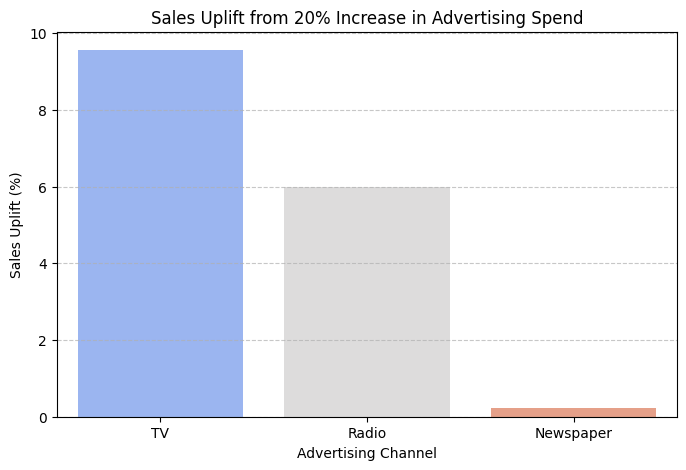

In [35]:
## Extract uplift percentages from simulation results
simulation_results = {
    'TV': sim_tv20['uplift_%'],
    'Radio': sim_radio20['uplift_%'],
    'Newspaper': sim_news20['uplift_%']}

sim_df = pd.DataFrame.from_dict(simulation_results, orient='index', columns=['Uplift_%'])

plt.figure(figsize=(8, 5))
sns.barplot(x=sim_df.index, y=sim_df['Uplift_%'], hue=sim_df.index, palette='coolwarm', legend=False)
plt.title('Sales Uplift from 20% Increase in Advertising Spend')
plt.xlabel('Advertising Channel')
plt.ylabel('Sales Uplift (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 The plot above visually represents how a 20% increase in spending on each advertising channel is projected to impact sales. Based on the simulation results:

* **TV Advertising:** A 20% increase in TV ad spend is predicted to result in a substantial 9.56% uplift in sales. This indicates that TV is highly effective in driving sales growth.

* **Radio Advertising:** A 20% increase in Radio ad spend is expected to lead to a 5.98% uplift in sales. While less than TV, this is still a significant positive impact, making Radio an important channel.

* **Newspaper Advertising:** A 20% increase in Newspaper ad spend shows a very minimal 0.22% uplift in sales. This reinforces the finding that Newspaper advertising has a much weaker influence on sales compared to TV and Radio for the same proportional budget increase.

In summary, the plot clearly highlights the varying effectiveness of each advertising channel, with TV and Radio being the most impactful for increasing sales, and Newspaper showing negligible returns.

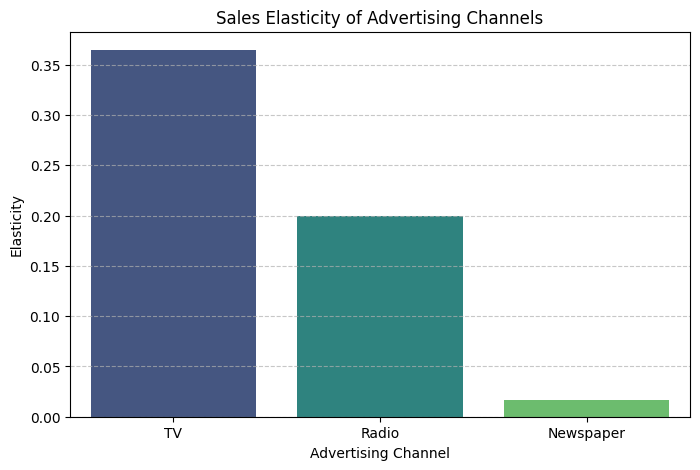

In [36]:
## Convert elasticities dictionary to a pandas Series for easy plotting
elasticities_series = pd.Series(elasticities)

plt.figure(figsize=(8, 5))
sns.barplot(x=elasticities_series.index, y=elasticities_series.values, hue=elasticities_series.index, palette='viridis', legend=False)
plt.title('Sales Elasticity of Advertising Channels')
plt.xlabel('Advertising Channel')
plt.ylabel('Elasticity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 An elasticity value indicates the percentage change in sales you can expect for every one percent change in advertising spend.

Here's what the plot reveals:

* **TV Advertising (Elasticity ≈ 0.36):** TV has the highest elasticity. This means that a 1% increase in TV advertising spend is projected to lead to approximately a 0.36% increase in sales. This indicates that TV advertising is quite effective in driving sales, and changes in TV spend have a noticeable impact.

* **Radio Advertising (Elasticity ≈ 0.20):** Radio advertising also shows a positive elasticity, but lower than TV. A 1% increase in Radio advertising spend is projected to result in approximately a 0.20% increase in sales. This suggests that Radio is also an effective channel, though slightly less potent than TV for the same proportional investment.

* **Newspaper Advertising (Elasticity ≈ 0.017):** Newspaper advertising has a very low elasticity. A 1% increase in Newspaper advertising spend is projected to result in only about a 0.017% increase in sales. This reinforces the finding that Newspaper advertising has a minimal impact on sales, meaning that even a significant proportional increase in spend will yield very little sales growth.

In summary, the plot clearly demonstrates that TV advertising is the most elastic (most responsive to changes in spend), followed by Radio, while Newspaper advertising is largely inelastic (changes in spend have little effect on sales). This aligns with the previous analyses and reinforces the idea of reallocating budget away from Newspaper towards TV and Radio for better sales impact.